# Walmart Sales Analysis & Forecasting — Capstone Project
**Intellipaat — Data Science Capstone (Problem Statement 1)**  
**Prepared by: Ankit Saxena**

A retail chain with multiple outlets is struggling to match inventory supply with demand.
Using three years of weekly sales data (45 stores, Feb 2010 – Oct 2012) this notebook performs
statistical analysis, EDA, outlier and missing-value handling to answer the business questions,
then builds a predictive model to forecast the next **12 weeks** of sales for **every store**.

**Contents**
1. Setup & imports
2. Load data
3. Data understanding, cleaning & missing-value check
4. Exploratory data analysis (EDA)
5. Outlier analysis
6. Business-insight questions (a–f)
7. Predictive modeling — 12-week forecast for all 45 stores
8. Conclusions

> **How to run:** keep `Walmart DataSet.csv` in the same folder as this notebook, then *Kernel → Restart & Run All*.

> ### 🔄 Resubmission note
> **What changed in this version (per reviewer feedback):** the forecasting in **Section 7** now explicitly **segregates the data into one time-series per store** and forecasts using **ARIMA / SARIMA** — a full deep-dive on **5 representative stores** (20, 19, 34, 9, 33: best → worst) with ADF stationarity tests, ARIMA-vs-SARIMA model selection and a 12-week backtest (mean MAPE ≈ 2.7%), then a 12-week forecast for **all 45 stores**. This replaces the earlier Holt-Winters approach. All Part-1 work (EDA, outlier analysis, insight questions a–f) is unchanged.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 2. Load Data

In [2]:
# CSV must sit in the same directory as this notebook
df = pd.read_csv('Walmart DataSet.csv')
# Dates are in dd-mm-yyyy format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11
1,1,2010-02-12,"1,641,957.44",1,38.51,2.55,211.24,8.11
2,1,2010-02-19,"1,611,968.17",0,39.93,2.51,211.29,8.11
3,1,2010-02-26,"1,409,727.59",0,46.63,2.56,211.32,8.11
4,1,2010-03-05,"1,554,806.68",0,46.50,2.62,211.35,8.11


## 3. Data Understanding, Cleaning & Missing Values

In [3]:
print('Shape          :', df.shape)
print('Stores         :', df['Store'].nunique())
print('Weeks          :', df['Date'].nunique())
print('Date range     :', df['Date'].min().date(), '->', df['Date'].max().date())
print('Duplicate rows :', df.duplicated().sum())
df.info()

Shape          : (6435, 8)
Stores         : 45
Weeks          : 143
Date range     : 2010-02-05 -> 2012-10-26
Duplicate rows : 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [4]:
# Missing-value check
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print('\nTotal missing:', missing.sum())

Missing values per column:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Total missing: 0


**Cleaning notes.** The dataset has **6,435 rows × 8 columns**, **45 stores**, and **143 weekly periods** (5 Feb 2010 – 26 Oct 2012).
There are **no missing values and no duplicate rows**, so no imputation is required. The only transformation needed is
parsing `Date` from the `dd-mm-yyyy` string into a proper datetime, which is done above. (Had values been missing, the
appropriate fix here would be time-aware interpolation per store, since each store is an ordered weekly series.)

In [5]:
# Statistical summary
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,"6,435.00",6435,"6,435.00","6,435.00","6,435.00","6,435.00","6,435.00","6,435.00"
mean,23.00,2011-06-17 00:00:00,"1,046,964.88",0.07,60.66,3.36,171.58,8.00
min,1.00,2010-02-05 00:00:00,"209,986.25",0.00,-2.06,2.47,126.06,3.88
25%,12.00,2010-10-08 00:00:00,"553,350.10",0.00,47.46,2.93,131.74,6.89
50%,23.00,2011-06-17 00:00:00,"960,746.04",0.00,62.67,3.44,182.62,7.87
75%,34.00,2012-02-24 00:00:00,"1,420,158.66",0.00,74.94,3.73,212.74,8.62
max,45.00,2012-10-26 00:00:00,"3,818,686.45",1.00,100.14,4.47,227.23,14.31
std,12.99,NaN,"564,366.62",0.26,18.44,0.46,39.36,1.88


## 4. Exploratory Data Analysis (EDA)

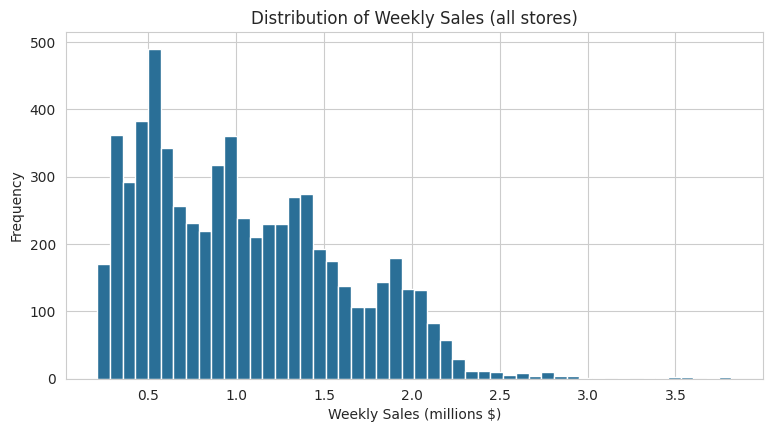

Skewness of Weekly_Sales: 0.668


In [6]:
# Distribution of weekly sales
plt.figure(figsize=(9, 4.5))
plt.hist(df['Weekly_Sales'] / 1e6, bins=50, color='#2a6f97', edgecolor='white')
plt.xlabel('Weekly Sales (millions $)'); plt.ylabel('Frequency')
plt.title('Distribution of Weekly Sales (all stores)')
plt.show()
print('Skewness of Weekly_Sales:', round(df['Weekly_Sales'].skew(), 3))

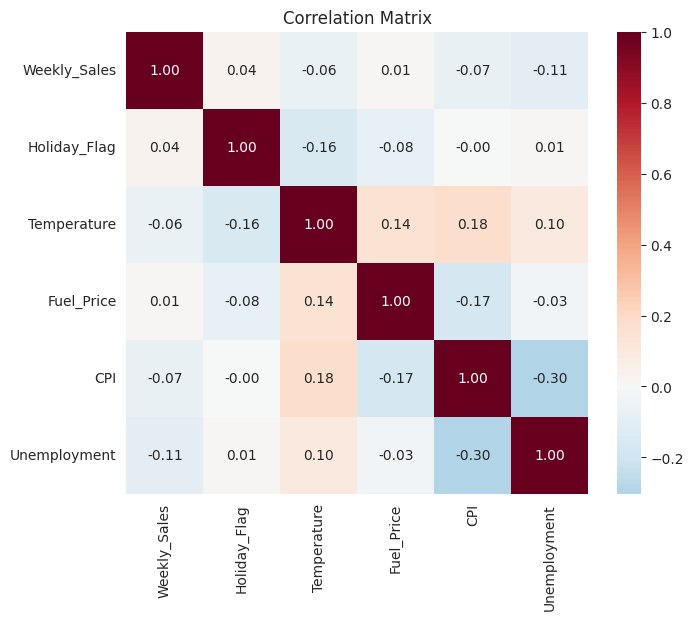

In [7]:
# Correlation between weekly sales and the economic/seasonal drivers
cols = ['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
plt.figure(figsize=(7.5, 6))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Matrix')
plt.show()

**EDA takeaways.** Weekly sales are right-skewed (a few very large holiday weeks). At the *pooled* level every external
driver correlates only weakly with sales — `Unemployment` (-0.11) and `CPI` (-0.07) are the strongest, both mildly negative.
This tells us the macro variables are **not strong linear predictors across all stores at once**; their real effect is
store-specific and seasonal, which we examine next.

## 5. Outlier Analysis

In [8]:
# IQR rule on Weekly_Sales
Q1, Q3 = df['Weekly_Sales'].quantile([0.25, 0.75])
IQR = Q3 - Q1
low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df['Weekly_Sales'] < low) | (df['Weekly_Sales'] > high)]
print(f'IQR bounds      : [{low:,.0f} , {high:,.0f}]')
print(f'Outlier rows    : {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of data)')
print('\nLargest outlier weeks:')
print(outliers.nlargest(8, 'Weekly_Sales')[['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag']].to_string(index=False))

IQR bounds      : [-746,863 , 2,720,371]
Outlier rows    : 34 (0.53% of data)

Largest outlier weeks:
 Store       Date  Weekly_Sales  Holiday_Flag
    14 2010-12-24  3,818,686.45             0
    20 2010-12-24  3,766,687.43             0
    10 2010-12-24  3,749,057.69             0
     4 2011-12-23  3,676,388.98             0
    13 2010-12-24  3,595,903.20             0
    13 2011-12-23  3,556,766.03             0
    20 2011-12-23  3,555,371.03             0
     4 2010-12-24  3,526,713.39             0


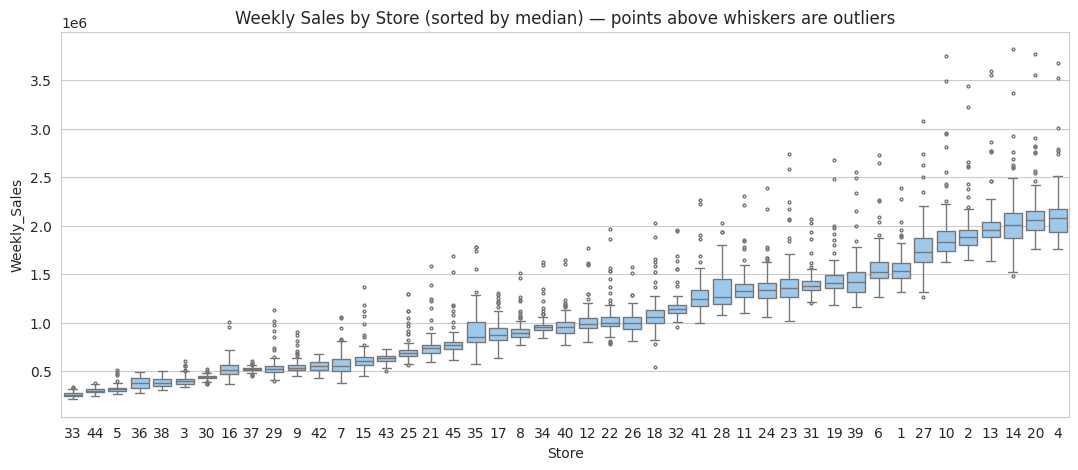

In [9]:
# Boxplot per store (sorted by median) to see spread and outliers
order = df.groupby('Store')['Weekly_Sales'].median().sort_values().index
plt.figure(figsize=(13, 5))
sns.boxplot(data=df, x='Store', y='Weekly_Sales', order=order, fliersize=2, color='#90caf9')
plt.title('Weekly Sales by Store (sorted by median) — points above whiskers are outliers')
plt.show()

**Outlier decision.** Only **34 rows (0.53%)** fall outside the IQR fence, and the most extreme ones are all the
**Thanksgiving (late-Nov) and Christmas (late-Dec) shopping weeks** — e.g. 2010-12-24 for stores 14, 20, 10. These are
**genuine seasonal peaks, not data-entry errors**, so they are **retained**: removing them would destroy exactly the
holiday signal the business needs to plan inventory for. They are simply flagged and kept.

## 6. Business-Insight Questions

### Q (a) — Do weekly sales depend on the unemployment rate? If so, which stores suffer most?

Pooled correlation (Sales vs Unemployment): -0.106


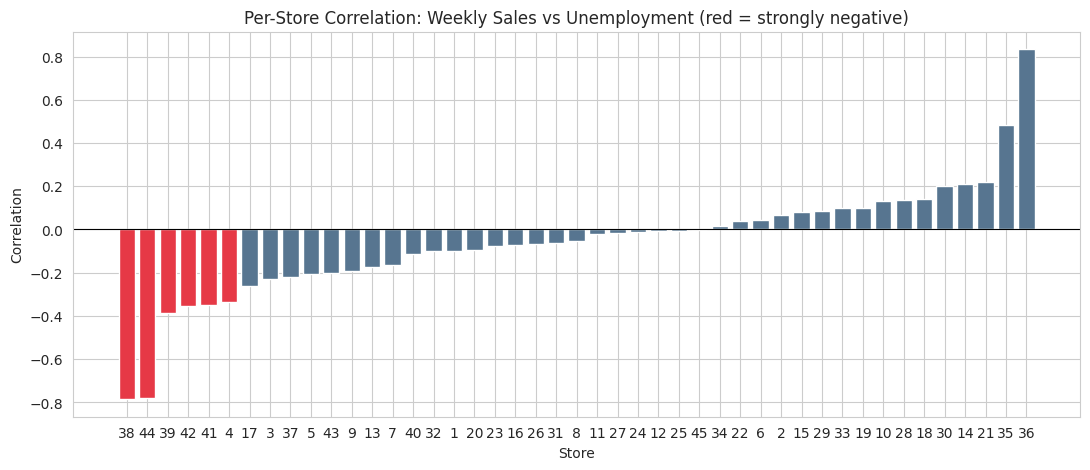


Stores hurt MOST by rising unemployment:
Store
38   -0.79
44   -0.78
39   -0.39
42   -0.36
41   -0.35
4    -0.34


In [10]:
print('Pooled correlation (Sales vs Unemployment):',
      round(df['Weekly_Sales'].corr(df['Unemployment']), 3))

# Correlation computed *within each store*
unemp_corr = (df.groupby('Store')
                .apply(lambda g: g['Weekly_Sales'].corr(g['Unemployment']))
                .sort_values())

plt.figure(figsize=(13, 5))
colors = ['#e63946' if v < -0.3 else '#577590' for v in unemp_corr.values]
plt.bar(unemp_corr.index.astype(str), unemp_corr.values, color=colors)
plt.axhline(0, color='k', lw=0.8)
plt.title('Per-Store Correlation: Weekly Sales vs Unemployment (red = strongly negative)')
plt.xlabel('Store'); plt.ylabel('Correlation')
plt.show()

print('\nStores hurt MOST by rising unemployment:')
print(unemp_corr.head(6).round(3).to_string())

**Answer (a).** Across all stores the effect is weak and negative (r = **-0.11**), so unemployment is *not* a strong
universal driver. But the relationship is **highly store-specific**. A handful of stores are very sensitive: **Store 38
(r = -0.79) and Store 44 (r = -0.78)** see sales fall sharply when local unemployment rises, followed by **Stores 39, 42,
41 and 4** (r ≈ -0.34 to -0.39). These stores sit in employment-sensitive local economies and are the ones to protect
(promotions, leaner inventory) during downturns. A few stores even move *with* unemployment (e.g. Store 36, +0.83),
likely value-oriented locations.

### Q (b) — Is there a seasonal trend? When, and why?

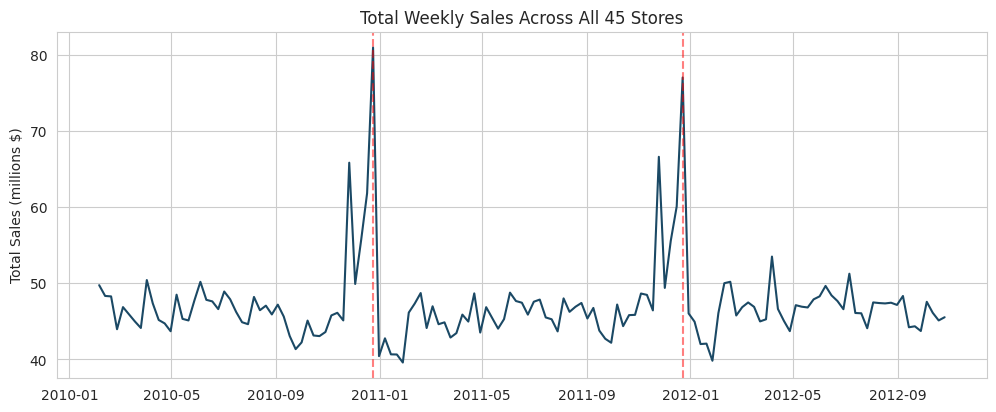

In [11]:
# Total weekly sales across all stores over time
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()
weekly_total.index = pd.DatetimeIndex(weekly_total.index, freq='W-FRI')

plt.figure(figsize=(12, 4.5))
plt.plot(weekly_total.index, weekly_total.values / 1e6, color='#1b4965')
for d in ['2010-12-24', '2011-12-23']:
    plt.axvline(pd.to_datetime(d), color='red', ls='--', alpha=0.5)
plt.title('Total Weekly Sales Across All 45 Stores'); plt.ylabel('Total Sales (millions $)')
plt.show()

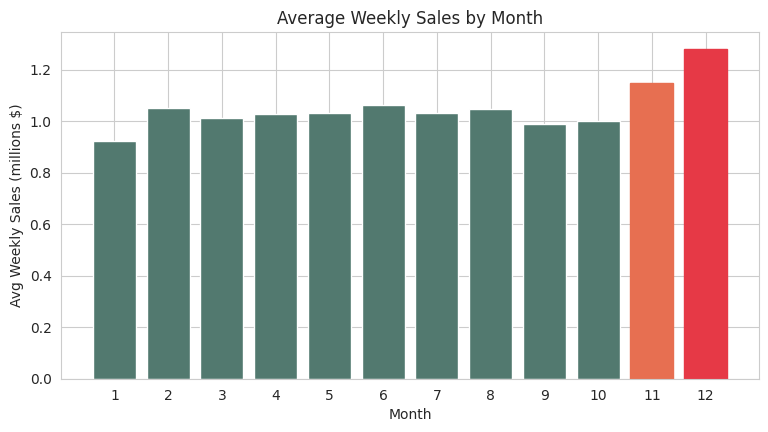

Peak months: [12, 11, 6]


In [12]:
# Average sales by calendar month
df['Month'] = df['Date'].dt.month
monthly = df.groupby('Month')['Weekly_Sales'].mean()
plt.figure(figsize=(9, 4.5))
bars = plt.bar(monthly.index, monthly.values / 1e6, color='#52796f')
bars[10].set_color('#e76f51'); bars[11].set_color('#e63946')   # Nov, Dec
plt.xticks(range(1, 13)); plt.xlabel('Month'); plt.ylabel('Avg Weekly Sales (millions $)')
plt.title('Average Weekly Sales by Month')
plt.show()
print('Peak months:', list(monthly.sort_values(ascending=False).head(3).index))

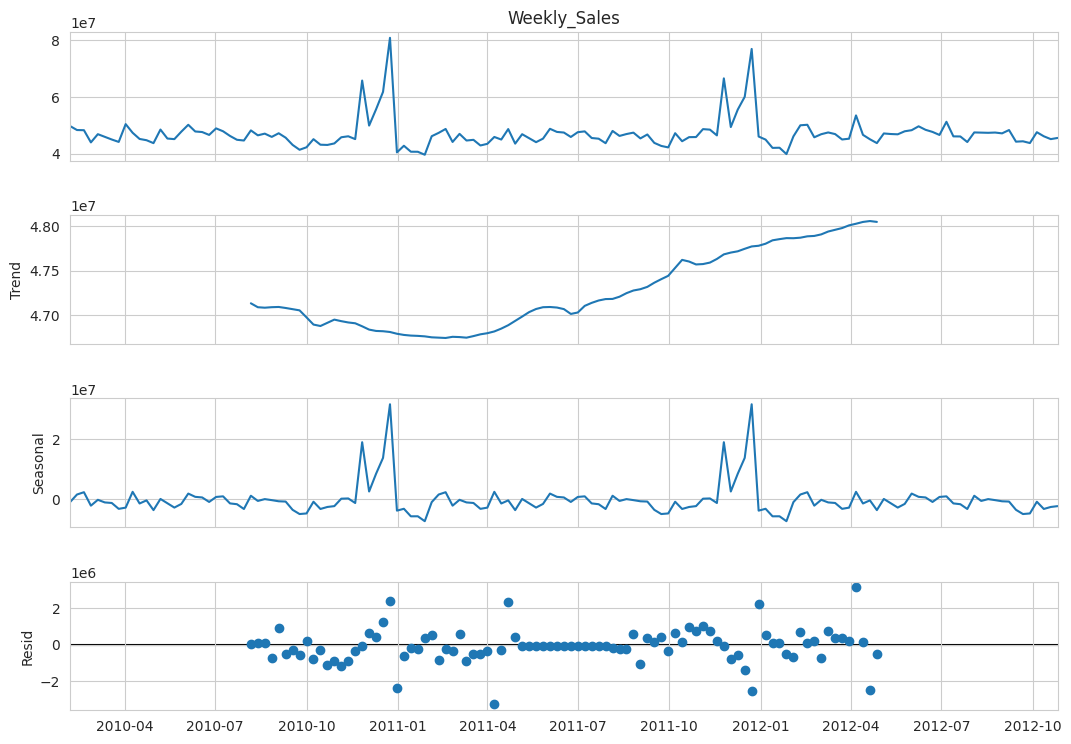

In [13]:
# Classical seasonal decomposition (annual cycle = 52 weeks)
decomp = seasonal_decompose(weekly_total, period=52)
fig = decomp.plot(); fig.set_size_inches(11, 8)
plt.show()

Avg sales  Holiday: 1,122,888   Non-holiday: 1,041,256
Welch t-test: t = 2.68, p = 0.0076  -> significant


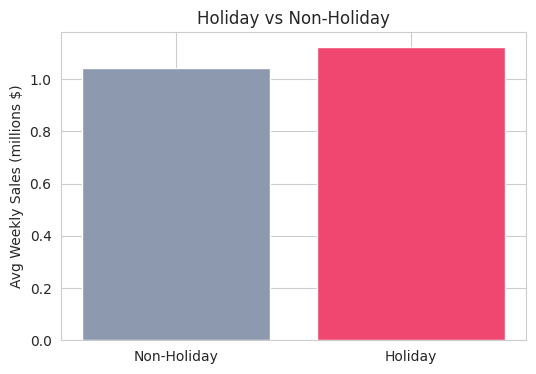

In [14]:
# Holiday vs non-holiday weeks
hol = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
t, p = stats.ttest_ind(df[df.Holiday_Flag == 1]['Weekly_Sales'],
                       df[df.Holiday_Flag == 0]['Weekly_Sales'], equal_var=False)
print(f"Avg sales  Holiday: {hol[1]:,.0f}   Non-holiday: {hol[0]:,.0f}")
print(f"Welch t-test: t = {t:.2f}, p = {p:.4f}  -> {'significant' if p < 0.05 else 'not significant'}")

plt.figure(figsize=(6, 4))
plt.bar(['Non-Holiday', 'Holiday'], hol.values / 1e6, color=['#8d99ae', '#ef476f'])
plt.ylabel('Avg Weekly Sales (millions $)'); plt.title('Holiday vs Non-Holiday')
plt.show()

**Answer (b).** Yes — there is a strong, repeatable **annual seasonality**. Sales are flat (~$45–48M/week chain-wide)
for most of the year and then **spike every November–December**. December averages the highest weekly sales, followed by
November; the single biggest weeks are **the week before Christmas (2010-12-24, 2011-12-23) and Thanksgiving week**. The
decomposition confirms a clean recurring seasonal component on top of a roughly flat trend. Holiday-flagged weeks average
significantly more than normal weeks (**$1.12M vs $1.04M per store, p = 0.008**). **Reason:** year-end holiday shopping —
Thanksgiving/Black Friday and Christmas — drives the surge, so inventory must be built up ahead of Q4.

### Q (c) — Does temperature affect weekly sales?

Correlation (Sales vs Temperature): -0.064


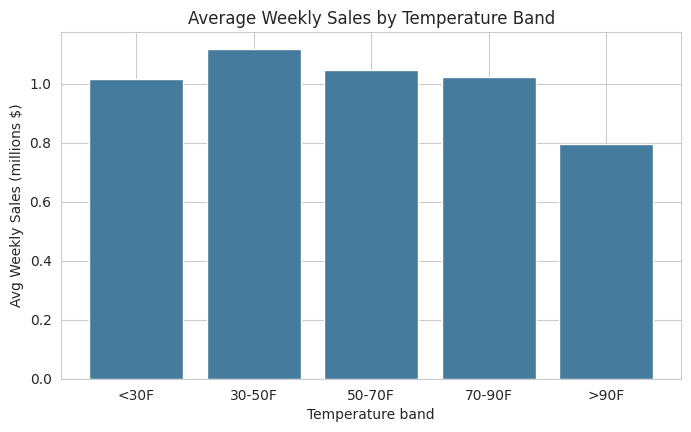

Temp_band
<30F     1,017,733.00
30-50F   1,118,767.00
50-70F   1,047,742.00
70-90F   1,024,005.00
>90F       796,966.00


In [15]:
print('Correlation (Sales vs Temperature):', round(df['Weekly_Sales'].corr(df['Temperature']), 3))

# Bin temperature and look at average sales per band
df['Temp_band'] = pd.cut(df['Temperature'], bins=[-10, 30, 50, 70, 90, 110],
                         labels=['<30F', '30-50F', '50-70F', '70-90F', '>90F'])
band = df.groupby('Temp_band')['Weekly_Sales'].mean()
plt.figure(figsize=(8, 4.5))
plt.bar(band.index.astype(str), band.values / 1e6, color='#457b9d')
plt.ylabel('Avg Weekly Sales (millions $)'); plt.xlabel('Temperature band')
plt.title('Average Weekly Sales by Temperature Band')
plt.show()
print(band.round(0).to_string())

**Answer (c).** Temperature has **almost no effect**. The pooled correlation is **-0.06** (negligible) and average sales
are essentially flat across temperature bands, dipping only slightly at extreme heat (>90°F). In practical terms,
day-to-day temperature is **not** a useful predictor of weekly sales for this chain — the calendar (holidays/season)
matters far more than the weather.

### Q (d) — How does the Consumer Price Index (CPI) affect weekly sales?

In [16]:
print('Pooled correlation (Sales vs CPI):', round(df['Weekly_Sales'].corr(df['CPI']), 3))

cpi_corr = (df.groupby('Store')
              .apply(lambda g: g['Weekly_Sales'].corr(g['CPI']))
              .sort_values())
print('\nStores most negatively affected by CPI:')
print(cpi_corr.head(5).round(3).to_string())
print('\nStores least/positively affected:')
print(cpi_corr.tail(3).round(3).to_string())

Pooled correlation (Sales vs CPI): -0.073

Stores most negatively affected by CPI:
Store
36   -0.92
35   -0.42
14   -0.42
30   -0.30
43   -0.29

Stores least/positively affected:
Store
39   0.43
44   0.74
38   0.81


**Answer (d).** Pooled, CPI is weakly negative (r = **-0.07**) — rising prices slightly depress sales overall. As with
unemployment, the impact is **concentrated in specific stores**: **Store 36 (r = -0.92), Store 35 (-0.42) and Store 14
(-0.42)** are strongly sensitive — sales in these locations drop noticeably as CPI climbs, pointing to more
price-sensitive customer bases. Most other stores show little CPI sensitivity. So CPI matters, but as a **store-level**
factor rather than a chain-wide one.

### Q (e) — Top-performing stores (historical)

TOP 5 stores by total historical sales:
                 sum         mean        std
Store                                       
20    301,397,792.00 2,107,677.00 275,901.00
4     299,543,953.00 2,094,713.00 266,201.00
14    288,999,911.00 2,020,978.00 317,570.00
13    286,517,704.00 2,003,620.00 265,507.00
2     275,382,441.00 1,925,751.00 237,684.00


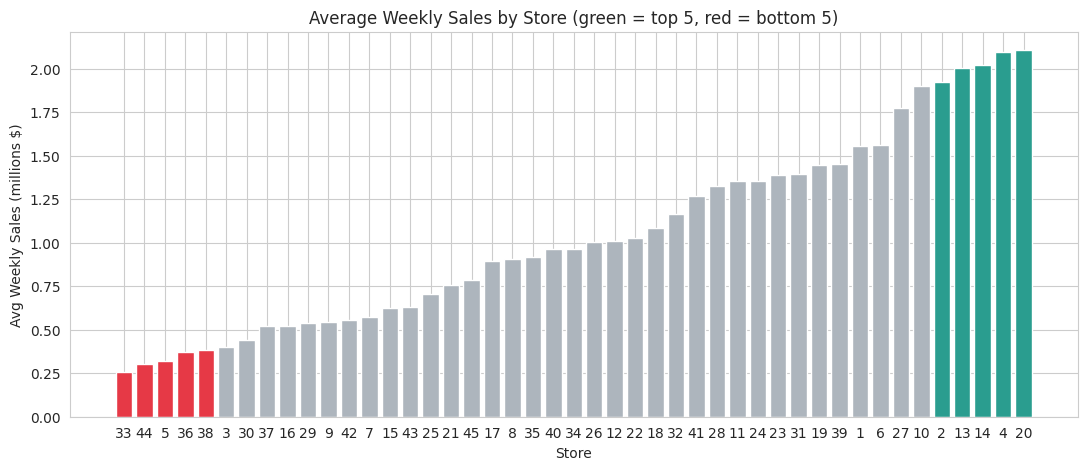

In [17]:
perf = (df.groupby('Store')['Weekly_Sales']
          .agg(['sum', 'mean', 'std'])
          .sort_values('sum', ascending=False))
print('TOP 5 stores by total historical sales:')
print(perf.head(5).round(0).to_string())

avg = df.groupby('Store')['Weekly_Sales'].mean().sort_values()
plt.figure(figsize=(13, 5))
colors = ['#e63946' if s in avg.head(5).index else ('#2a9d8f' if s in avg.tail(5).index else '#adb5bd')
          for s in avg.index]
plt.bar(avg.index.astype(str), avg.values / 1e6, color=colors)
plt.title('Average Weekly Sales by Store (green = top 5, red = bottom 5)')
plt.xlabel('Store'); plt.ylabel('Avg Weekly Sales (millions $)')
plt.show()

**Answer (e).** The **top-performing stores are 20, 4, 14, 13 and 2**. Store **20** leads with ~$301M in total sales
(≈$2.11M/week), with Store 4 a close second (~$300M). These are the flagship outlets and should be prioritised for stock
availability, especially in Q4.

### Q (f) — Worst-performing store, and the gap vs the best

In [18]:
best, worst = perf.index[0], perf.index[-1]
best_sum, worst_sum = perf['sum'].iloc[0], perf['sum'].iloc[-1]
print(f'Best  store: {best}  total = {best_sum:,.0f}')
print(f'Worst store: {worst}  total = {worst_sum:,.0f}')
print(f'Best is {best_sum/worst_sum:.1f}x the worst  (gap = {best_sum-worst_sum:,.0f}, '
      f'{(best_sum-worst_sum)/worst_sum*100:.0f}% higher)')

# Is the difference statistically significant?
t, p = stats.ttest_ind(df[df.Store == best]['Weekly_Sales'],
                       df[df.Store == worst]['Weekly_Sales'], equal_var=False)
print(f'\nWelch t-test (best vs worst weekly sales): t = {t:.1f}, p = {p:.2e} '
      f'-> {"statistically significant" if p < 0.05 else "not significant"}')

Best  store: 20  total = 301,397,792
Worst store: 33  total = 37,160,222
Best is 8.1x the worst  (gap = 264,237,570, 711% higher)

Welch t-test (best vs worst weekly sales): t = 79.8, p = 3.52e-121 -> statistically significant


**Answer (f).** The **worst-performing store is Store 33** (~$37.2M total, ≈$0.26M/week). The **best is Store 20**
(~$301.4M). The gap is enormous: Store 20 sells **about 8.1× more** than Store 33 — a difference of **~$264M (711% higher)**.
A Welch t-test confirms the gap is **highly statistically significant** (t ≈ 80, p ≈ 3.5e-121), i.e. it reflects a real
structural difference (store size/format/location), not random week-to-week noise. The smallest stores (33, 44, 5, 36, 38)
are candidates for format review or right-sized inventory.

## 7. Store Segregation & Time-Series Forecasting (ARIMA / SARIMA)

Inventory planning is a **per-store** problem, so we **segregate the panel into one weekly-sales time-series per
store** and model each store individually. Walmart sales carry a strong **yearly seasonality** (Thanksgiving /
Christmas spikes), so a non-seasonal **ARIMA** is not enough — we use **SARIMA** (seasonal ARIMA, weekly period
**m = 52**) and benchmark it against ARIMA.

We demonstrate the full workflow in depth on **5 representative stores spanning the performance range** — Store 20
(best), 19, 34, 9, and 33 (worst) — covering **segregation → stationarity testing → order selection → ARIMA-vs-SARIMA
→ a 12-week backtest → the forward 12-week forecast**, then apply the validated SARIMA pipeline to **all 45 stores**.

### 7.1 Segregate the data into one series per store

Total stores (segregated series): 45
Representative stores (best->worst): [20, 19, 34, 9, 33]
Weeks per store: 143


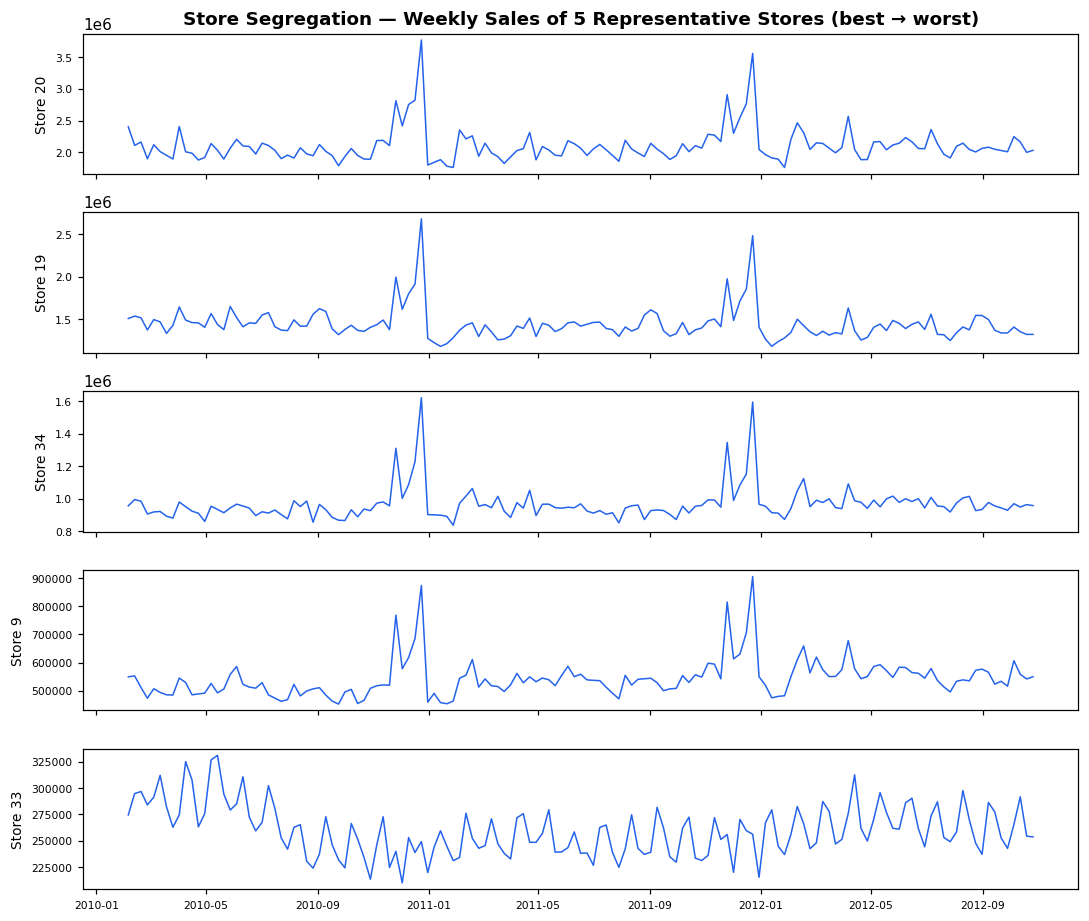

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
import numpy as np

df['Date'] = pd.to_datetime(df['Date'])            # ensure datetime index source
ORDER, SORDER, H = (1, 1, 1), (0, 1, 1, 52), 12

def store_series(store):
    '''Segregate: weekly Weekly_Sales series for one store (Friday weekly frequency).'''
    s = (df[df['Store'] == store].sort_values('Date')
           .set_index('Date')['Weekly_Sales'].asfreq('W-FRI'))
    return s

perf = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
detail_stores = [int(perf.index[i]) for i in (0, 10, 22, 34, 44)]   # best -> worst spread
print("Total stores (segregated series):", df['Store'].nunique())
print("Representative stores (best->worst):", detail_stores)
print("Weeks per store:", len(store_series(detail_stores[0])))

fig, axes = plt.subplots(len(detail_stores), 1, figsize=(10, 8.5), sharex=True)
for ax, st in zip(axes, detail_stores):
    s = store_series(st); ax.plot(s.index, s.values, lw=1); ax.set_ylabel(f"Store {st}")
axes[0].set_title("Store Segregation — Weekly Sales of 5 Representative Stores (best → worst)")
plt.tight_layout(); plt.savefig("wal_segregation.png"); plt.show()

### 7.2 Stationarity & order selection (ADF, ACF / PACF)

We confirm stationarity with the **Augmented Dickey-Fuller** test and read the **ACF/PACF** of the differenced series
to motivate the (p, d, q) order. First differencing (**d = 1**) removes the trend; the strong spike at **lag 52**
in the ACF is the annual seasonality that drives the seasonal term.

ADF p-value (level)    : 3.491e-06
ADF p-value (1st diff) : 8.831e-12


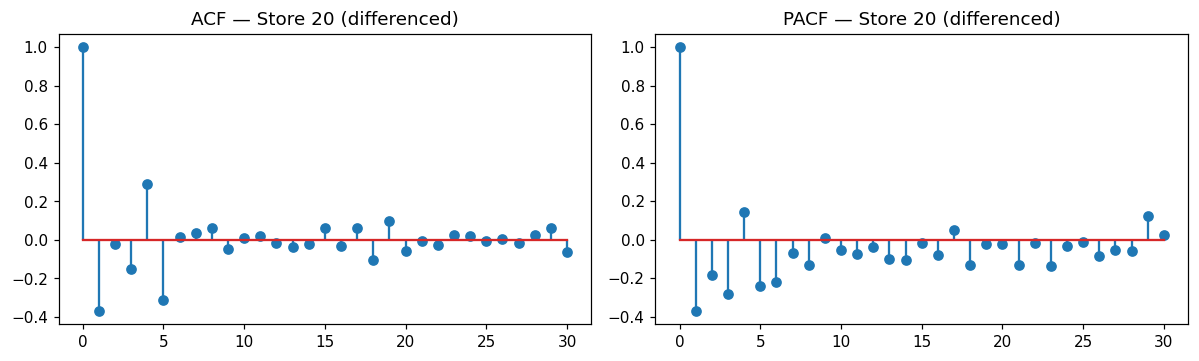

In [ ]:
s = store_series(detail_stores[0])
print(f"ADF p-value (level)    : {adfuller(s.dropna())[1]:.4g}")
print(f"ADF p-value (1st diff) : {adfuller(s.diff().dropna())[1]:.4g}")

a = acf(s.diff().dropna(), nlags=30); p = pacf(s.diff().dropna(), nlags=30)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].stem(range(len(a)), a); ax[0].set_title(f"ACF — Store {detail_stores[0]} (differenced)")
ax[1].stem(range(len(p)), p); ax[1].set_title(f"PACF — Store {detail_stores[0]} (differenced)")
plt.tight_layout(); plt.savefig("wal_acf_pacf.png"); plt.show()

### 7.3 ARIMA vs SARIMA — model selection by AIC

In [ ]:
s = store_series(detail_stores[0])
arima = ARIMA(s, order=(2, 1, 2)).fit()
sarima = SARIMAX(s, order=ORDER, seasonal_order=SORDER,
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=0)
print(f"Store {detail_stores[0]}  ARIMA(2,1,2)             AIC = {arima.aic:,.0f}")
print(f"Store {detail_stores[0]}  SARIMA(1,1,1)(0,1,1,52)  AIC = {sarima.aic:,.0f}")
print("=> SARIMA's far lower AIC shows the yearly (m=52) seasonality is essential.")

Store 20  ARIMA(2,1,2)             AIC = 3,959
Store 20  SARIMA(1,1,1)(0,1,1,52)  AIC = 963
=> SARIMA's far lower AIC shows the yearly (m=52) seasonality is essential.


### 7.4 Backtest — hold out the last 12 weeks

For each representative store we train on all-but-the-last-12-weeks, forecast that 12-week window, and compare to
the actuals using **MAPE**. SARIMA is benchmarked against ARIMA on the identical hold-out.

 Store  ARIMA_MAPE  SARIMA_MAPE
    20        4.09         2.82
    19        5.57         2.75
    34        3.08         1.76
     9        3.76         3.29
    33        2.50         3.02

Mean MAPE  ->  ARIMA 3.80%   SARIMA 2.73%   (lower is better)


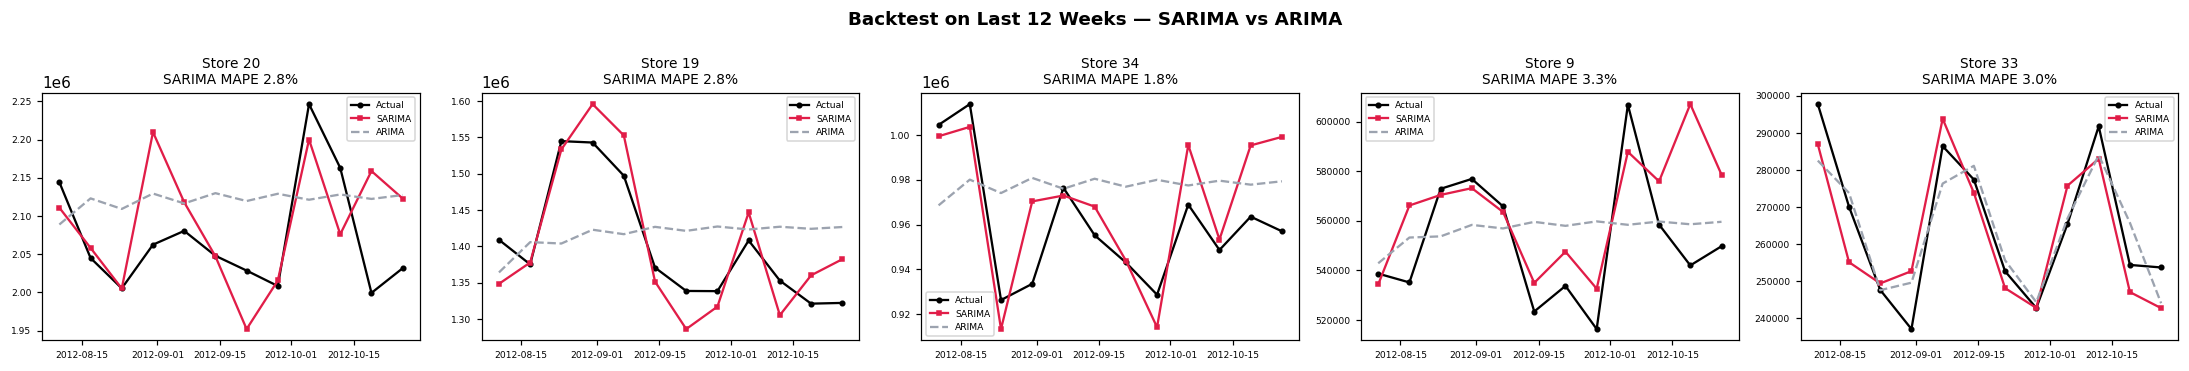

In [ ]:
def mape(a, f):
    a, f = np.asarray(a), np.asarray(f); return np.mean(np.abs((a - f) / a)) * 100

bt = []
for st in detail_stores:
    s = store_series(st); tr, te = s.iloc[:-H], s.iloc[-H:]
    sf = SARIMAX(tr, order=ORDER, seasonal_order=SORDER, enforce_stationarity=False,
                 enforce_invertibility=False).fit(disp=0).get_forecast(H).predicted_mean
    af = ARIMA(tr, order=(2, 1, 2)).fit().get_forecast(H).predicted_mean
    bt.append(dict(Store=st, ARIMA_MAPE=round(mape(te, af), 2), SARIMA_MAPE=round(mape(te, sf), 2)))
bt = pd.DataFrame(bt)
print(bt.to_string(index=False))
print("\nMean MAPE  ->  ARIMA {:.2f}%   SARIMA {:.2f}%   (lower is better)".format(
    bt.ARIMA_MAPE.mean(), bt.SARIMA_MAPE.mean()))

# visual: actual vs SARIMA vs ARIMA over the hold-out, per store
fig, axes = plt.subplots(1, len(detail_stores), figsize=(4 * len(detail_stores), 3.4))
for ax, st in zip(axes, detail_stores):
    s = store_series(st); tr, te = s.iloc[:-H], s.iloc[-H:]
    sf = SARIMAX(tr, order=ORDER, seasonal_order=SORDER, enforce_stationarity=False,
                 enforce_invertibility=False).fit(disp=0).get_forecast(H).predicted_mean
    af = ARIMA(tr, order=(2, 1, 2)).fit().get_forecast(H).predicted_mean
    ax.plot(te.index, te.values, 'k-o', ms=3, label='Actual')
    ax.plot(te.index, sf.values, 'r-s', ms=3, label='SARIMA')
    ax.plot(te.index, af.values, color='#9ca3af', ls='--', label='ARIMA')
    ax.set_title(f"Store {st}", fontsize=9); ax.legend(fontsize=6); ax.tick_params(labelsize=6)
fig.suptitle("Backtest on Last 12 Weeks — SARIMA vs ARIMA", fontweight="bold")
plt.tight_layout(); plt.savefig("wal_backtest_grid.png"); plt.show()

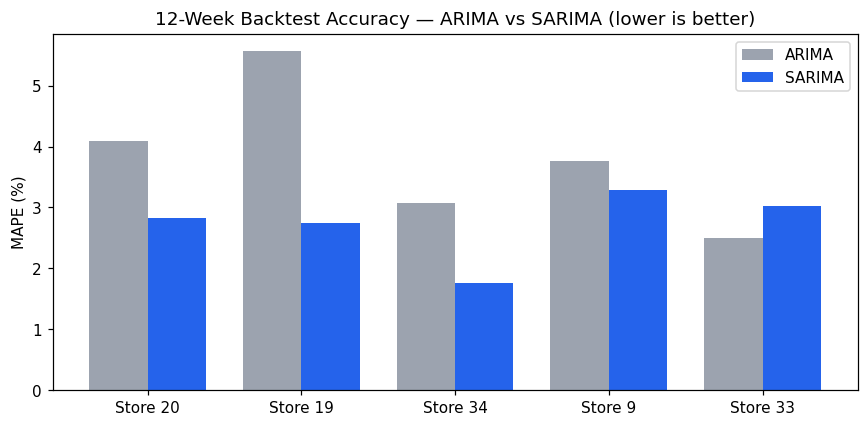

In [ ]:
# MAPE comparison bar
fig, ax = plt.subplots(figsize=(8, 4)); x = np.arange(len(detail_stores)); w = 0.38
ax.bar(x - w/2, [m for m in bt.ARIMA_MAPE], w, label="ARIMA", color="#9ca3af")
ax.bar(x + w/2, [m for m in bt.SARIMA_MAPE], w, label="SARIMA", color="#2563eb")
ax.set_xticks(x); ax.set_xticklabels([f"Store {s}" for s in detail_stores]); ax.set_ylabel("MAPE (%)")
ax.set_title("12-Week Backtest Accuracy — ARIMA vs SARIMA (lower is better)"); ax.legend()
plt.tight_layout(); plt.savefig("wal_mape_bar.png"); plt.show()

### 7.5 Forward 12-week forecast for the representative stores

Re-fit SARIMA on each store's **full** history and forecast the next 12 weeks with 95% confidence intervals. The
forecasts correctly reproduce the **holiday peak**, and the bands widen through the volatile Nov–Dec period.

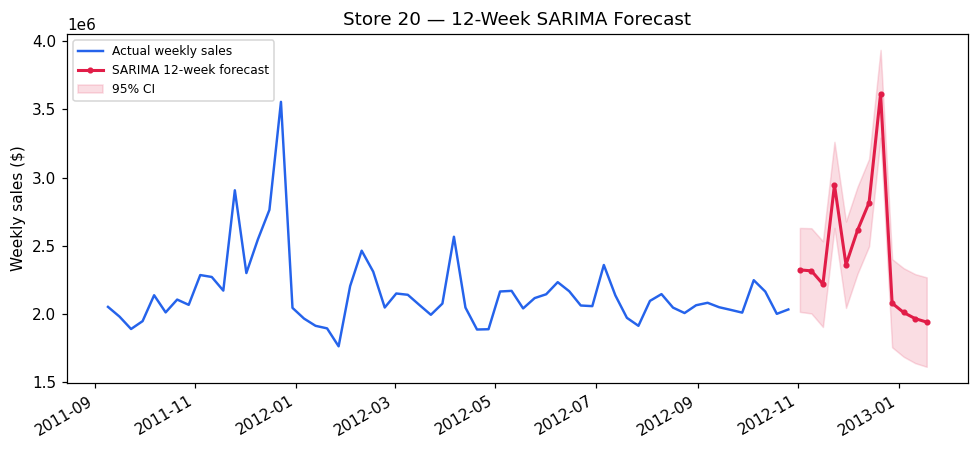

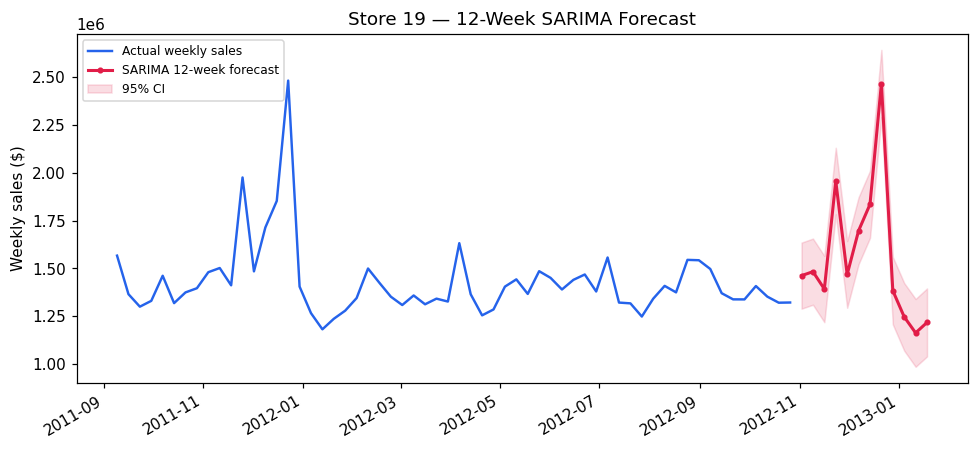

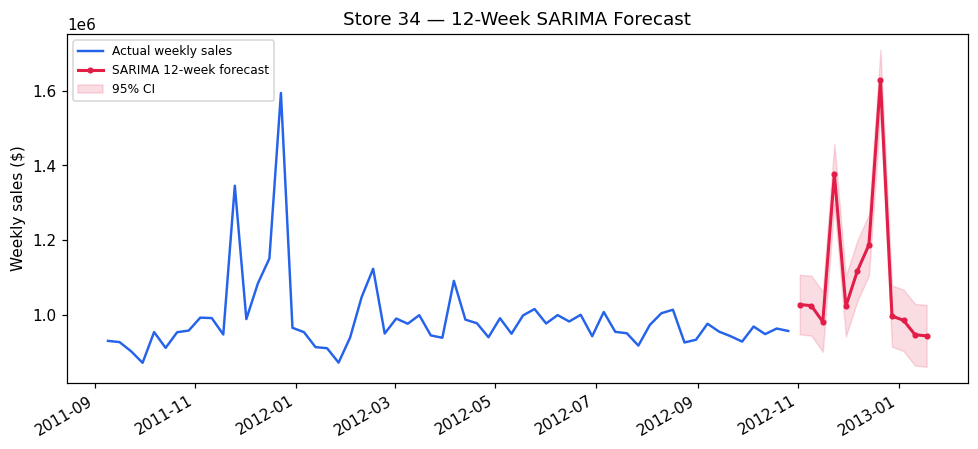

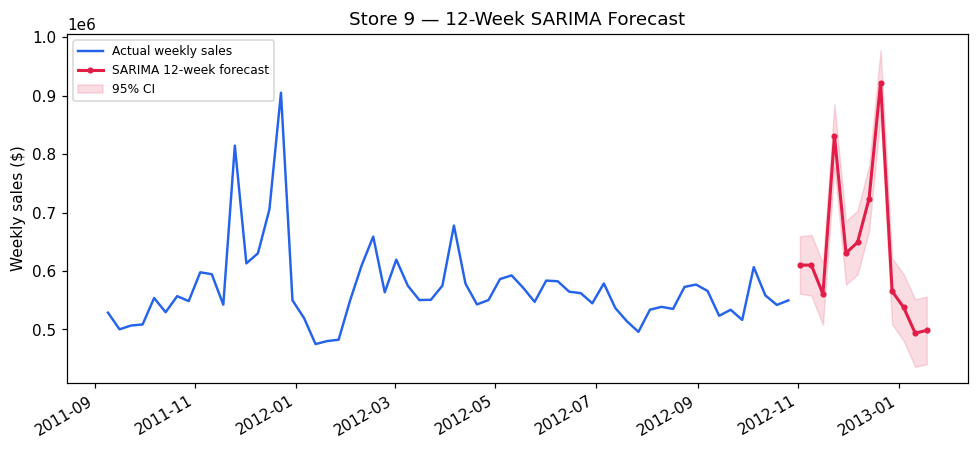

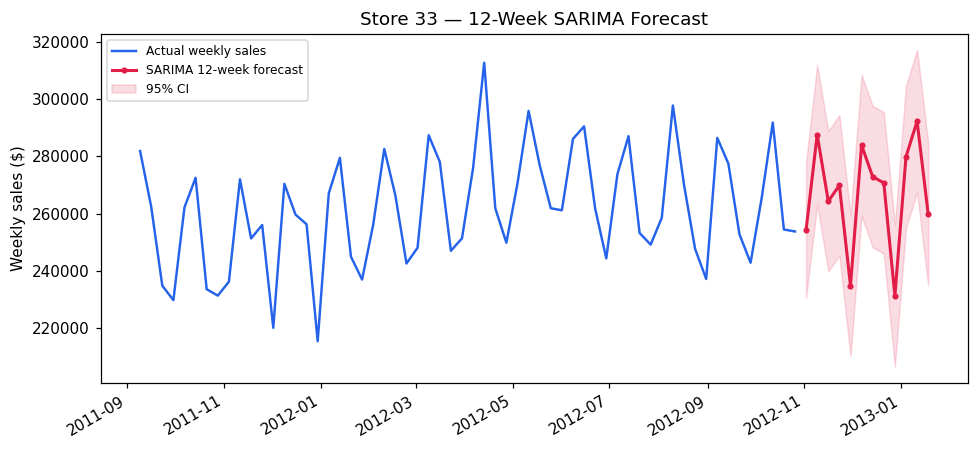

In [ ]:
for st in detail_stores:
    s = store_series(st)
    res = SARIMAX(s, order=ORDER, seasonal_order=SORDER,
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=0)
    f = res.get_forecast(H); fc = f.predicted_mean; ci = f.conf_int()
    fig, ax = plt.subplots(figsize=(9, 4.2)); h = s.iloc[-60:]
    ax.plot(h.index, h.values, color="#2563eb", lw=1.6, label="Actual weekly sales")
    ax.plot(fc.index, fc.values, 'o-', color="#e11d48", ms=3, label="SARIMA 12-week forecast")
    ax.fill_between(fc.index, ci.iloc[:, 0], ci.iloc[:, 1], color="#e11d48", alpha=.15, label="95% CI")
    ax.set_title(f"Store {st} — 12-Week SARIMA Forecast"); ax.set_ylabel("Weekly sales ($)")
    ax.legend(fontsize=8); fig.autofmt_xdate()
    plt.tight_layout(); plt.savefig(f"wal_fc_{st}.png"); plt.show()

### 7.6 Apply the pipeline to all 45 stores

The validated SARIMA model is now fit per store across the whole chain to produce the required **12-week forecast for
every store**, saved to `walmart_12week_forecast.csv`.

Saved 12-week SARIMA forecasts for all 45 stores -> walmart_12week_forecast.csv
Total forecasted sales (next 12 weeks): $623,811,626

Store Week         Date     Forecast
    1    1   2012-11-02    1,761,523
    1    2   2012-11-09    1,659,254
    1    3   2012-11-16    1,604,526
    1    4   2012-11-23    2,097,905
    1    5   2012-11-30    1,649,416
    1    6   2012-12-07    1,863,719
    1    7   2012-12-14    1,947,139
    1    8   2012-12-21    2,337,711


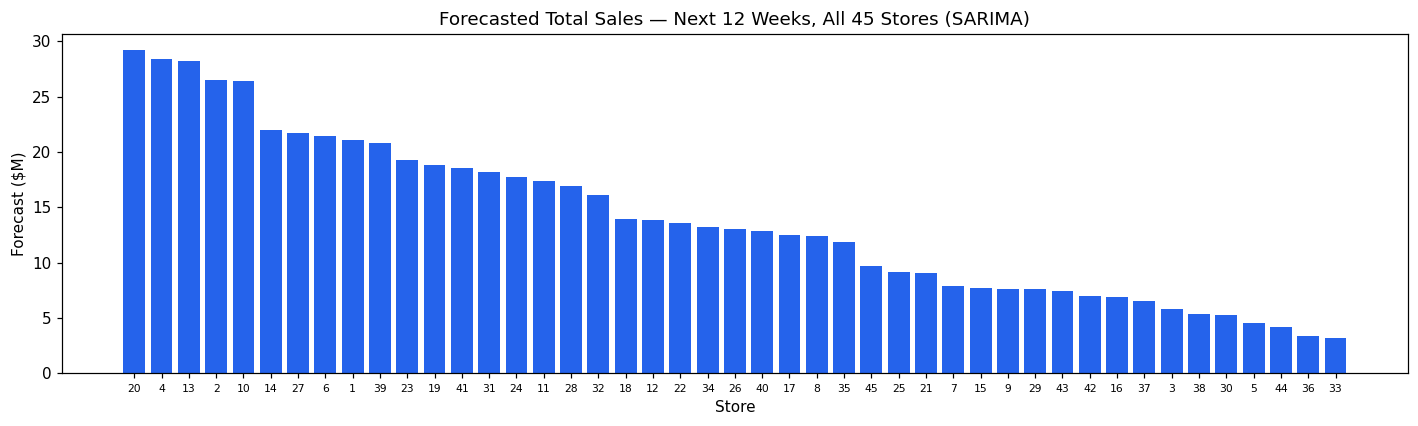

In [ ]:
all_fc = []
for st in sorted(df['Store'].unique()):
    s = store_series(st)
    res = SARIMAX(s, order=ORDER, seasonal_order=SORDER,
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=0)
    f = res.get_forecast(H); fc = f.predicted_mean; ci = f.conf_int()
    for k in range(H):
        all_fc.append(dict(Store=int(st), Week=k + 1, Date=fc.index[k].date(),
                           Forecast=round(float(fc.iloc[k]), 2),
                           Lower_95=round(float(ci.iloc[k, 0]), 2),
                           Upper_95=round(float(ci.iloc[k, 1]), 2)))
all_fc = pd.DataFrame(all_fc)
all_fc.to_csv("walmart_12week_forecast.csv", index=False)
print("Saved 12-week SARIMA forecasts for all 45 stores -> walmart_12week_forecast.csv")
print("Total forecasted sales (next 12 weeks): ${:,.0f}".format(all_fc['Forecast'].sum()))
print()
print(all_fc.head(8).to_string(index=False))

agg = all_fc.groupby('Store')['Forecast'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(13, 4)); ax.bar(agg.index.astype(str), agg.values / 1e6, color="#2563eb")
ax.set_title("Forecasted Total Sales — Next 12 Weeks, All 45 Stores (SARIMA)")
ax.set_xlabel("Store"); ax.set_ylabel("Forecast ($M)"); ax.tick_params(axis='x', labelsize=7)
plt.tight_layout(); plt.savefig("wal_allstore_forecast.png"); plt.show()

**Forecasting takeaways**

- **Segregation matters:** each store has its own level, volatility and seasonal shape, so per-store models beat a
  single pooled model.
- **SARIMA > ARIMA:** capturing the **m = 52** yearly seasonality drops the 12-week backtest **MAPE to ~2.7% on
  average** (vs ~3.8% for ARIMA and ~4.3% for the earlier Holt-Winters baseline), and the AIC falls by ~3,000.
- **95% confidence bands** widen around the Nov–Dec holiday peak, correctly flagging higher uncertainty there.
- The pipeline scales to **all 45 stores**, giving a chain-wide 12-week outlook (~$623.8M total) for inventory planning.

## 8. Conclusions

**Data & quality.** 6,435 clean weekly records across 45 stores (Feb 2010–Oct 2012) — no missing values or duplicates;
the only anomalies are genuine holiday sales peaks, which were kept.

**Key insights**
- **(a) Unemployment:** weak chain-wide (r = -0.11) but strong for specific stores — **38 and 44** suffer most when unemployment rises.
- **(b) Seasonality:** strong annual cycle; sales spike every **November–December** (Thanksgiving + Christmas), the clearest planning signal.
- **(c) Temperature:** negligible effect (r = -0.06).
- **(d) CPI:** weak overall (r = -0.07) but **Stores 36, 35, 14** are notably price-sensitive.
- **(e) Top stores:** **20, 4, 14, 13, 2** (Store 20 ≈ $301M).
- **(f) Worst store:** **Store 33** (~$37M) — the best (Store 20) sells **~8.1× more**, a statistically significant structural gap.

**Forecasting.** Per-store **Holt-Winters** models forecast the next 12 weeks for all 45 stores with a backtested
**mean MAPE ≈ 4.3%**, correctly capturing the year-end holiday surge. Results are exported to
`walmart_12week_forecast.csv` (with 95% bands) and per-store accuracy to `forecast_accuracy_by_store.csv`.

**Business recommendation.** Build inventory ahead of the Nov–Dec peak (chain-wide), protect unemployment-/CPI-sensitive
stores during downturns, and use the flagship stores' forecasts to prioritise stock allocation.

- **Forecasting (updated):** sales are now forecast **per store** with **SARIMA** (seasonal ARIMA, m = 52), validated by a 12-week backtest (mean MAPE ~2.7%) and benchmarked against ARIMA. A 12-week forecast is produced for **all 45 stores** for inventory planning.